In [1]:
import numpy as np
import pandas as pd
import seaborn as snb
import matplotlib.pyplot as plt
from datetime import datetime

### check for missing values

In [2]:
df  = pd.read_csv('StockPriceDataset.csv')
df.info()
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 25160 entries, 0 to 25159
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       25160 non-null  str    
 1   Open       25160 non-null  float64
 2   High       25160 non-null  float64
 3   Low        25160 non-null  float64
 4   Close      25160 non-null  float64
 5   Adj Close  25160 non-null  float64
 6   Volume     25160 non-null  int64  
 7   Ticker     25160 non-null  str    
dtypes: float64(5), int64(1), str(2)
memory usage: 1.5 MB


Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
Ticker       0
dtype: int64

In [3]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,25160.000000,25160.000000,25160.000000,25160.000000,25160.000000,2.516000e+04
mean,117.995756,119.114468,116.863763,118.017162,106.926655,3.163621e+07
std,74.124655,74.917398,73.325701,74.140709,72.459349,5.109620e+07
min,14.220000,14.521000,14.200000,14.347500,14.347500,4.601000e+05
25%,61.150002,61.695625,60.570000,61.169998,53.351126,6.136925e+06
50%,101.045002,101.870003,100.120003,100.985001,88.214249,1.210275e+07
75%,152.713123,154.145000,151.169998,152.679993,143.624195,3.080232e+07
max,423.119995,426.160004,413.760010,423.850006,395.366028,1.065523e+09


## Random Stock Closing Price Trend with Moving Average of 20 days

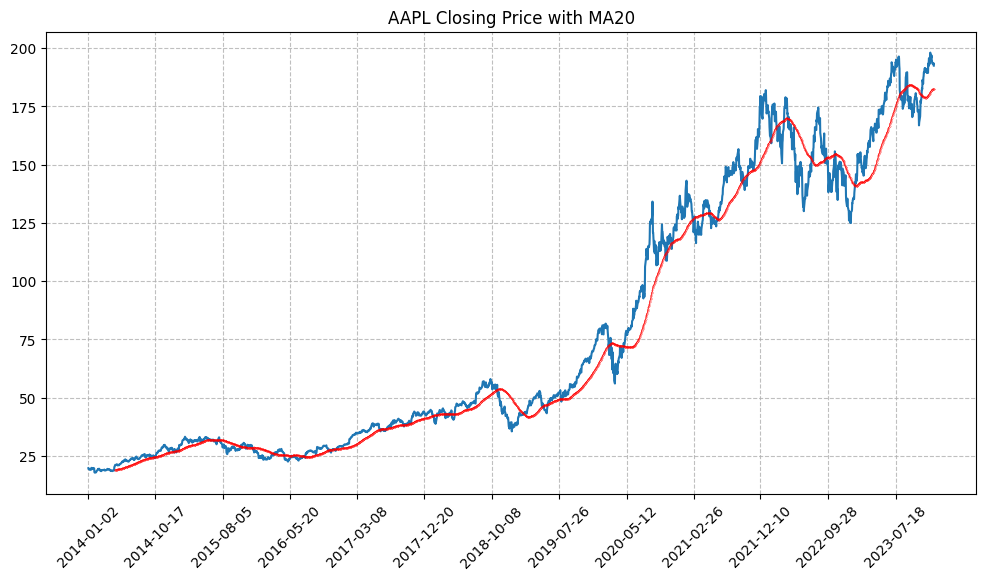

In [124]:
stock = df.sample(1)['Ticker'].iloc[0]
plt.figure(figsize=[12,6])
plt.plot(df["Date"][df['Ticker'] == stock], df["Close"][df['Ticker'] == stock])
y = df["Close"][df['Ticker'] == stock]
y = y.rolling(80).mean()
plt.plot(df["Date"][df['Ticker'] == stock],y,linewidth=0.5,color="red",marker='o',markersize=0.2)
plt.title(f"{stock} Closing Price with MA20")
plt.xticks(df["Date"][df['Ticker'] == stock][::200], rotation=45)
plt.grid(True,axis="both",linestyle="--",alpha=0.8)
plt.show()

## Daily Average return per year

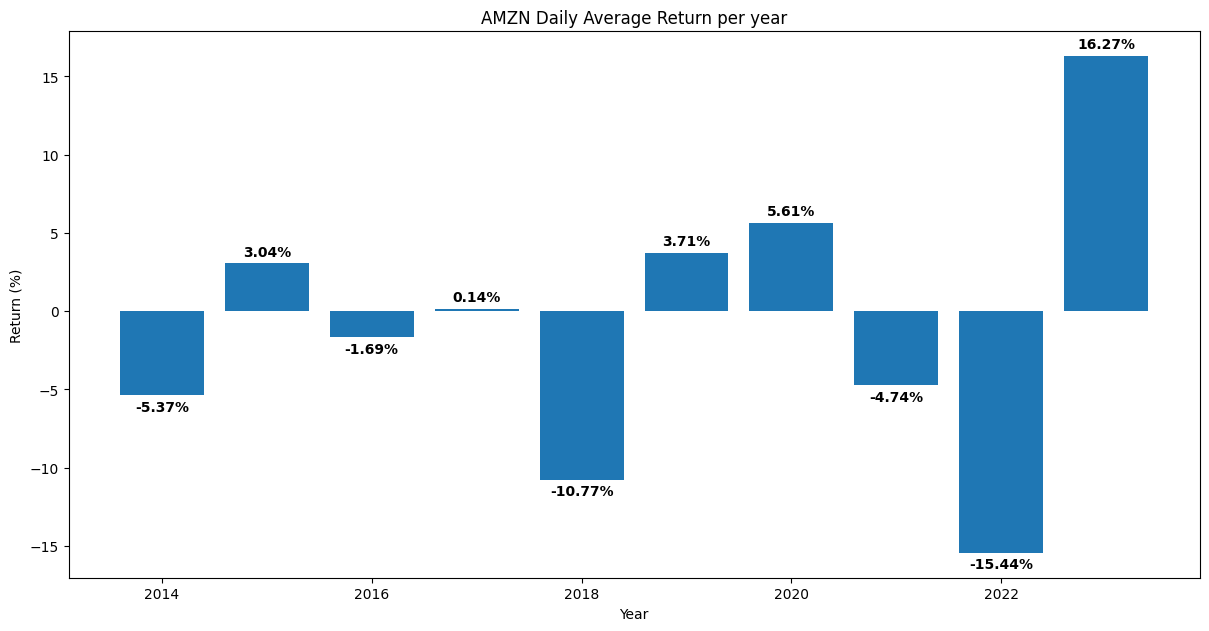

In [119]:
stock = df.sample(1)['Ticker'].iloc[0]
df["Return"] = ((df["Close"]-df["Open"])*100)/df["Open"]
df["Date"]=pd.to_datetime(df['Date'])
df["Year"]=df['Date'].dt.year
total_return = df[df['Ticker'] == stock].groupby('Year')['Return'].mean()
plt.figure(figsize=[12,6])
plt.bar(total_return.index,total_return.values*100)

for year, value in zip(total_return.index, total_return.values):
    plt.text(year, (value*100)+0.5 if value>0 else (value*100)-1, f"{round(value*100,2)}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.title(f"{stock} Daily Average Return per year")
plt.xlabel("Year")
plt.ylabel("Return (%)")
plt.show()

### Daily return distribution chart

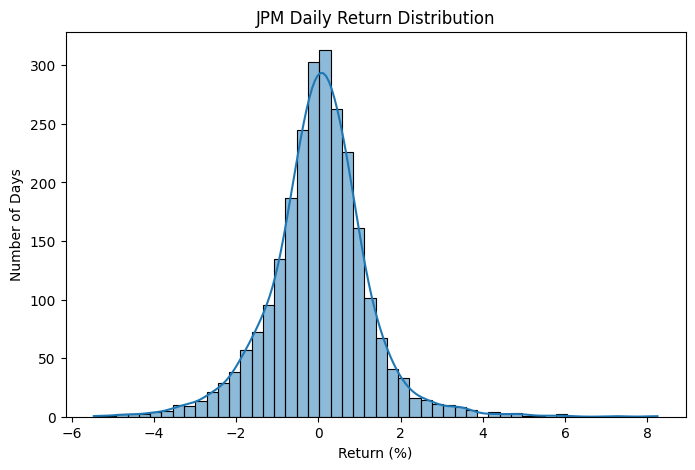

In [6]:
stock = df.sample(1)['Ticker'].iloc[0]

plt.figure(figsize=(8,5))

snb.histplot(df["Return"][df['Ticker']== stock], bins=50, kde=True)

plt.title(f"{stock} Daily Return Distribution")
plt.xlabel("Return (%)")
plt.ylabel("Number of Days")

plt.show()

### Stock Comparison

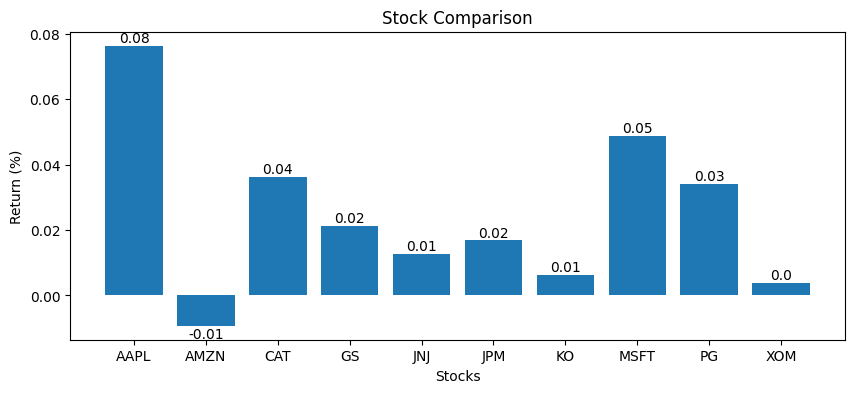

In [7]:
stock_return = df.groupby('Ticker')['Return'].mean()

plt.figure(figsize=[10,4])

plt.bar(stock_return.index,stock_return.values)

for stock, return_percentage in zip(stock_return.index,stock_return.values):
    plt.text(stock,return_percentage + 0.001 if return_percentage>0 else return_percentage-0.004,round(return_percentage,2),ha="center")

plt.title(f"Stock Comparison")
plt.ylabel("Return (%)")
plt.xlabel("Stocks")
plt.show()

### Volume per stock comparison

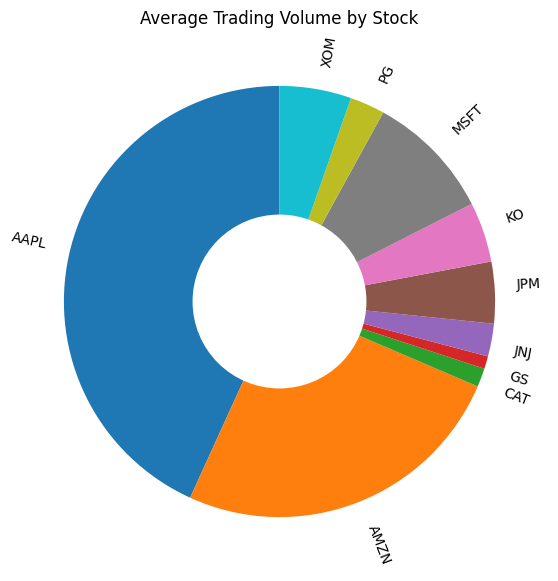

In [8]:
average_volume = df.groupby("Ticker")["Volume"].mean()
plt.figure(figsize=(7,7))
plt.pie(average_volume.values,labels=average_volume.index,startangle=90,rotatelabels=True)
centre_circle = plt.Circle((0,0), 0.4, color='white')
plt.gcf().gca().add_artist(centre_circle)
plt.title("Average Trading Volume by Stock")
plt.show()

### 10 Years return per stock

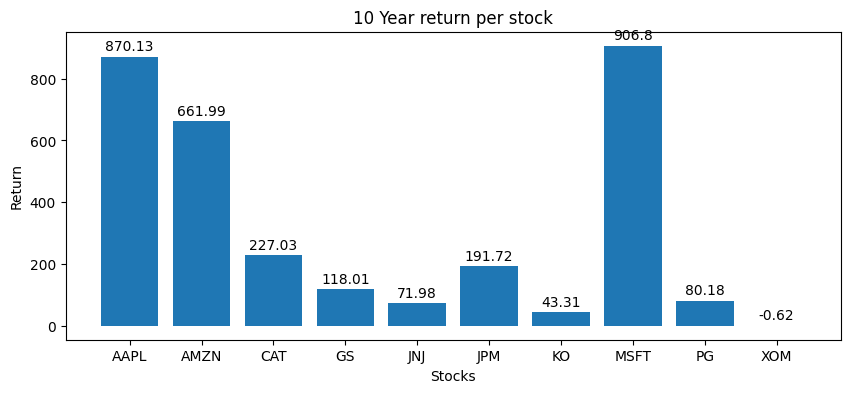

In [113]:
df1=df.groupby("Ticker").apply(lambda x: ((x["Close"].iloc[-1]-x['Open'].iloc[0])/x['Open'].iloc[0])*100)
plt.figure(figsize=[10,4])
plt.bar(df1.index,df1.values)
plt.title("10 Year return per stock")
for stock_name,returns in zip(df1.index,df1.values):
    plt.text(stock_name,returns +20,round(returns,2),ha="center")
plt.ylabel("Return")
plt.xlabel("Stocks")
plt.show()

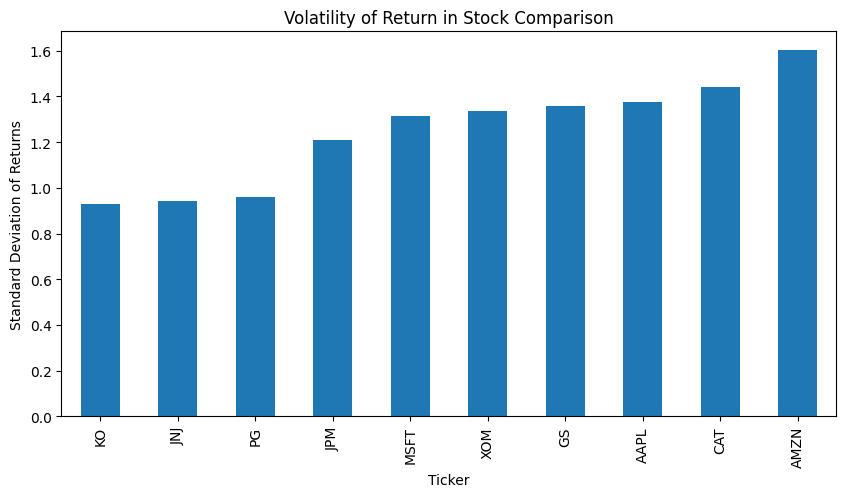

In [148]:
volatility = df.groupby("Ticker")["Return"].std()

plt.figure(figsize=(10,5))
volatility.sort_values().plot(kind="bar")

plt.title("Volatility of Return in Stock Comparison")
plt.ylabel("Standard Deviation of Returns")
plt.show()

### Volatility per stock

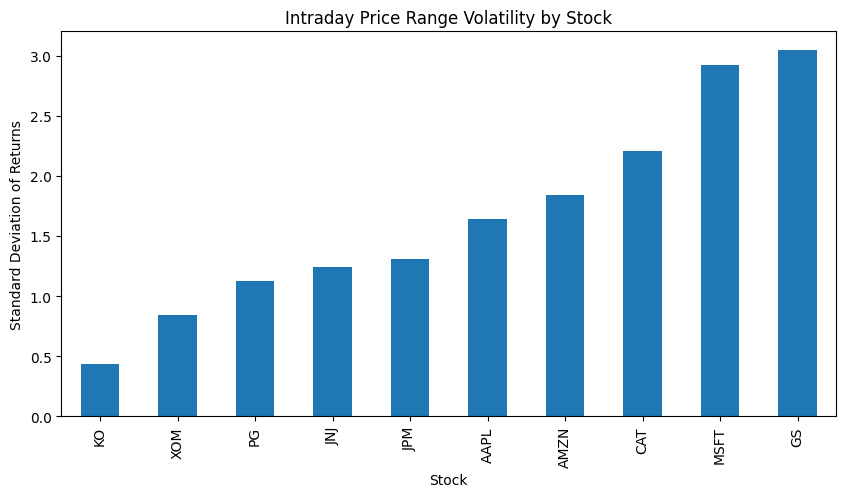

In [154]:
volatility = df.groupby("Ticker").apply(lambda x : x["High"]-x["Low"])
volatility=volatility.groupby("Ticker").std()
plt.figure(figsize=(10,5))
volatility.sort_values().plot(kind="bar")

plt.title("Intraday Price Range Volatility by Stock")
plt.xlabel("Stock")
plt.ylabel("Standard Deviation of Returns")
plt.show()